# Risk metrics

Rolling VaR/CVaR workflow using marginal models and an R-vine dependence
model. The setup cell keeps the dataset choice and calculation controls
together so the notebook remains self-contained.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.ticker as plticker

from pyscarcopula import RVineCopula
from pyscarcopula.contrib.empirical import cvar_emp_window
from pyscarcopula.contrib.risk_metrics import risk_metrics

## Data and calculation parameters

In [2]:
TICKERS = [
    "BTC-USD", "ETH-USD", "BNB-USD",
    "ADA-USD", "XRP-USD", "DOGE-USD",
]
GAMMA = 0.95
WINDOW = 250
N_MC = 100_000
METHOD = "scar-tm-ou"
MARGINALS_METHOD = "johnsonsu"

DATA_DIR = Path("data") if Path("data").exists() else Path("..") / "data"
prices = pd.read_csv(DATA_DIR / "crypto_prices.csv", index_col=0, sep=";")
returns = np.log(prices[TICKERS] / prices[TICKERS].shift(1)).iloc[501:1001]
d = len(TICKERS)

## Rolling risk estimates

In [ ]:
# estimation time ~ 2-3 min

risk_copula = RVineCopula()
result = risk_metrics(
    risk_copula,
    returns.values,
    window_len=WINDOW,
    gamma=GAMMA,
    N_mc=N_MC,
    marginals_method=MARGINALS_METHOD,
    method=METHOD,
    optimize_portfolio=False,
    portfolio_weight=np.ones(d) / d,
    n_jobs=10,
    truncation_level=2,
)

Fitting marginals (johnsonsu)...
gamma=0.95, N_mc=100000, method=scar-tm-ou, n_jobs=10


## Compare model and empirical CVaR

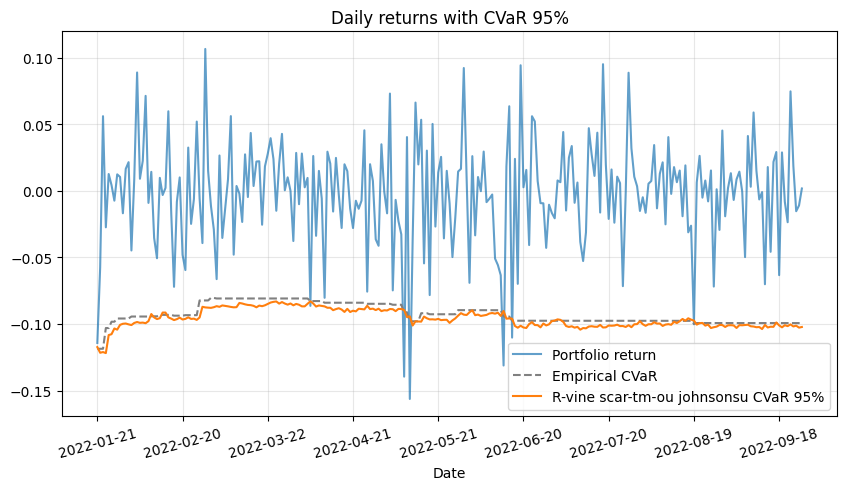

In [5]:
weight = result[GAMMA][N_MC]["weight"]
model_cvar = pd.Series(
    -result[GAMMA][N_MC]["cvar"],
    index=returns.index,
).shift(1)

daily_returns = ((np.exp(returns) - 1) * weight).sum(axis=1)
empirical_cvar = cvar_emp_window(
    daily_returns.values, 1 - GAMMA, WINDOW
)

start, stop = WINDOW, len(returns) - 1
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    np.clip(daily_returns, -0.2, 0.2)[start:stop],
    label="Portfolio return",
    alpha=0.7,
)
ax.plot(
    empirical_cvar[start:stop],
    label="Empirical CVaR",
    linestyle="dashed",
    color="gray",
)
ax.plot(
    model_cvar[start:stop],
    label=f"R-vine {METHOD} {MARGINALS_METHOD} CVaR 95%",
)
ax.xaxis.set_major_locator(plticker.MultipleLocator(base=30.0))
ax.set(title="Daily returns with CVaR 95%", xlabel="Date")
ax.tick_params(axis="x", labelrotation=15)
ax.grid(alpha=0.3)
ax.legend()
plt.show()